In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from scipy import stats
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, roc_auc_score, classification_report,
    confusion_matrix, RocCurveDisplay
)

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
#load pre-split data
train = pd.read_csv("data/processed/ea_ml_train.csv")
test  = pd.read_csv("data/processed/ea_ml_test.csv")

print("Train shape:", train.shape, " years:", sorted(train["year"].unique()))
print("Test  shape:", test.shape,  " years:", sorted(test["year"].unique()))

Train shape: (26, 32)  years: [np.int64(2018), np.int64(2019)]
Test  shape: (65, 32)  years: [np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]


In [3]:
MEDIAN = 3.8

features = [
    "hpi_growth_roll3_mean",
    "hicp_growth_roll3_mean",
    "gdp_growth_roll3_mean",
    "unemp_rate_roll3_mean",
    "marriage_rate_lag1"
]

train = train[features + ["marriage_rate"]].dropna().reset_index(drop=True)
test  = test[features  + ["marriage_rate"]].dropna().reset_index(drop=True)

y_train = (train["marriage_rate"] > MEDIAN).astype(int)
y_test  = (test["marriage_rate"]  > MEDIAN).astype(int)

print("Train rows:", len(train), "  class balance:", y_train.value_counts().to_dict())
print("Test  rows:", len(test),  "  class balance:", y_test.value_counts().to_dict())

Train rows: 26   class balance: {1: 15, 0: 11}
Test  rows: 65   class balance: {0: 36, 1: 29}


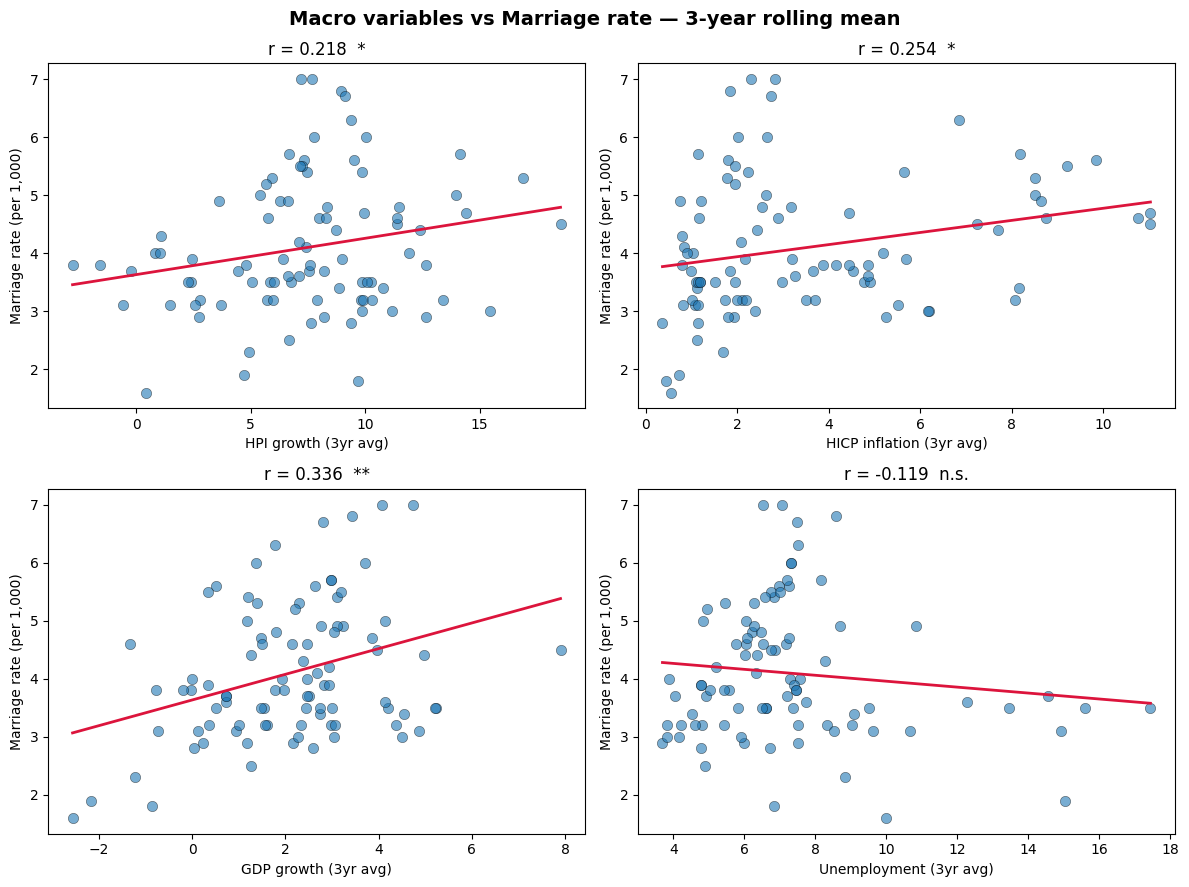

In [4]:
all_data = pd.concat([train, test])

labels = ['HPI growth (3yr avg)', 'HICP inflation (3yr avg)', 'GDP growth (3yr avg)', 'Unemployment (3yr avg)']
cols   = ['hpi_growth_roll3_mean', 'hicp_growth_roll3_mean', 'gdp_growth_roll3_mean', 'unemp_rate_roll3_mean']

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
fig.suptitle("Macro variables vs Marriage rate — 3-year rolling mean", fontsize=14, fontweight="bold")

for i in range(4):
    ax    = axes[i // 2][i % 2]
    x     = all_data[cols[i]]
    y     = all_data["marriage_rate"]
    slope, intercept, r, p, _ = stats.linregress(x, y)
    sig   = "***" if p < 0.001 else ("**" if p < 0.01 else ("*" if p < 0.05 else "n.s."))
    x_line = np.linspace(x.min(), x.max(), 100)

    ax.scatter(x, y, alpha=0.6, edgecolors="k", linewidths=0.4, s=55)
    ax.plot(x_line, slope * x_line + intercept, color="crimson", linewidth=2)
    ax.set_xlabel(labels[i])
    ax.set_ylabel("Marriage rate (per 1,000)")
    ax.set_title(f"r = {r:.3f}  {sig}")

plt.tight_layout()
plt.savefig("figures/lr_scatter_roll3mean.png", dpi=200, bbox_inches="tight")
plt.show()

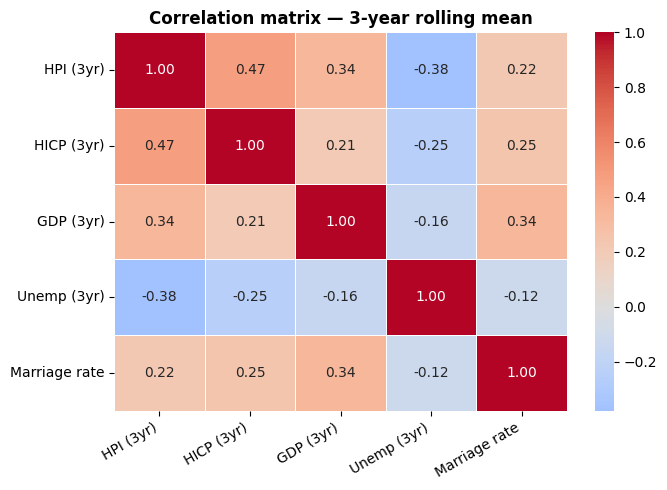

In [5]:
all_data = pd.concat([train, test])

corr_cols   = ["hpi_growth_roll3_mean", "hicp_growth_roll3_mean", "gdp_growth_roll3_mean", "unemp_rate_roll3_mean", "marriage_rate"]
tick_labels = ["HPI (3yr)", "HICP (3yr)", "GDP (3yr)", "Unemp (3yr)", "Marriage rate"]

corr_matrix = all_data[corr_cols].corr().round(2)

plt.figure(figsize=(7, 5))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            linewidths=0.5, xticklabels=tick_labels, yticklabels=tick_labels)
plt.title("Correlation matrix — 3-year rolling mean", fontsize=12, fontweight="bold")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig("figures/lr_corr_roll3mean.png", dpi=200, bbox_inches="tight")
plt.show()

In [6]:
X_train = train[features].values
X_test  = test[features].values

scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print("X_train:", X_train.shape)
print("X_test: ", X_test.shape)

X_train: (26, 5)
X_test:  (65, 5)


In [7]:
param_dist = {
    "C":        [0.001, 0.01, 0.05, 0.1, 0.5, 1.0, 5.0, 10.0],
    "penalty":  ["l1", "l2"],
    "solver":   ["liblinear"],
    "max_iter": [2000],
}

model = LogisticRegression(class_weight="balanced", random_state=42)

search = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_dist,
    n_iter=40,
    scoring="f1",
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=0
)

search.fit(X_train, y_train)
best_model = search.best_estimator_

print("Best hyperparameters:")
for k, v in sorted(search.best_params_.items()):
    print(f"  {k}: {v}")
print(f"\nBest CV F1: {search.best_score_:.4f}")

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 16 is smaller than n_iter=40. Running 16 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Best hyperparameters:
  C: 0.5
  max_iter: 2000
  penalty: l1
  solver: liblinear

Best CV F1: 0.8800


In [8]:
y_proba_train = best_model.predict_proba(X_train)[:, 1]
y_proba_test  = best_model.predict_proba(X_test)[:, 1]

from sklearn.metrics import f1_score

thresholds = np.linspace(0.01, 0.99, 200)
best_thr, best_f1 = 0.5, -1

for thr in thresholds:
    preds = (y_proba_train >= thr).astype(int)
    f1 = f1_score(y_train, preds, zero_division=0)
    if f1 > best_f1:
        best_f1, best_thr = f1, thr

print(f"Best threshold: {best_thr:.3f}  (train F1 = {best_f1:.4f})")

y_pred_train = (y_proba_train >= best_thr).astype(int)
y_pred_test  = (y_proba_test  >= best_thr).astype(int)

print()
print("Train")
print("  Accuracy:", round(accuracy_score(y_train, y_pred_train), 4))
print("  ROC-AUC: ", round(roc_auc_score(y_train, y_proba_train), 4))
print()
print("Test")
print("  Accuracy:", round(accuracy_score(y_test, y_pred_test), 4))
print("  ROC-AUC: ", round(roc_auc_score(y_test, y_proba_test), 4))
print()
print("Classification report (test):")
print(classification_report(y_test, y_pred_test,
      target_names=["Below median", "Above median"], zero_division=0))

Best threshold: 0.232  (train F1 = 1.0000)

Train
  Accuracy: 1.0
  ROC-AUC:  1.0

Test
  Accuracy: 0.8462
  ROC-AUC:  0.9339

Classification report (test):
              precision    recall  f1-score   support

Below median       0.88      0.83      0.86        36
Above median       0.81      0.86      0.83        29

    accuracy                           0.85        65
   macro avg       0.84      0.85      0.85        65
weighted avg       0.85      0.85      0.85        65



/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/_plotting.py:175: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


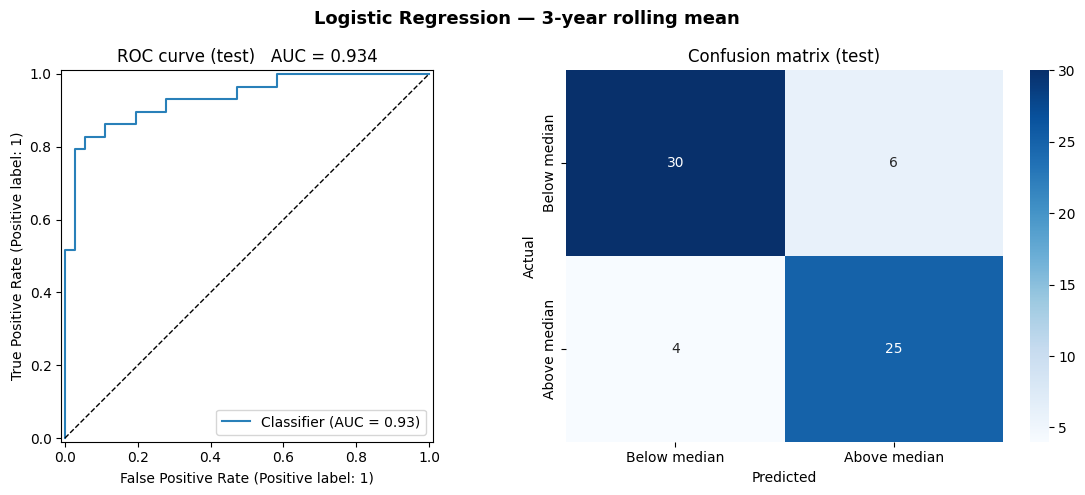

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Logistic Regression — 3-year rolling mean", fontsize=13, fontweight="bold")

RocCurveDisplay.from_predictions(y_test, y_proba_test, ax=axes[0], color="#2980b9")
axes[0].plot([0, 1], [0, 1], "k--", linewidth=1)
axes[0].set_title(f"ROC curve (test)   AUC = {roc_auc_score(y_test, y_proba_test):.3f}")

cm = confusion_matrix(y_test, y_pred_test)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[1],
            xticklabels=["Below median", "Above median"],
            yticklabels=["Below median", "Above median"])
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")
axes[1].set_title("Confusion matrix (test)")

plt.tight_layout()
plt.savefig("figures/lr_roc_cm_roll3mean.png", dpi=200, bbox_inches="tight")
plt.show()

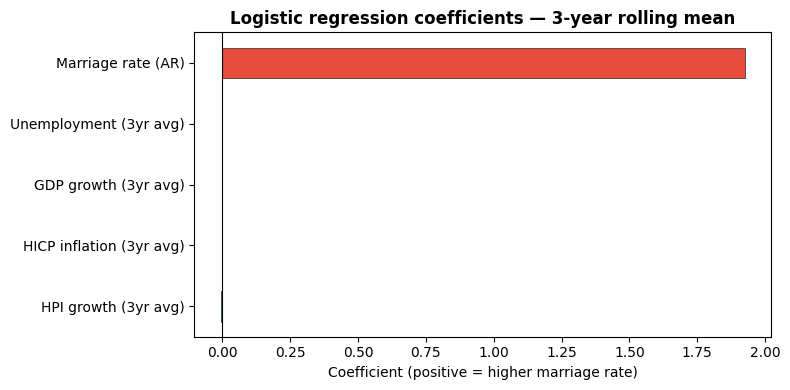

In [10]:
feat_labels = ['HPI growth (3yr avg)', 'HICP inflation (3yr avg)', 'GDP growth (3yr avg)', 'Unemployment (3yr avg)', 'Marriage rate (AR)']

coefs = pd.Series(best_model.coef_[0], index=feat_labels)
coefs = coefs.sort_values()
colors = ["#e74c3c" if v > 0 else "#2980b9" for v in coefs]

plt.figure(figsize=(8, 4))
coefs.plot.barh(color=colors, edgecolor="k", linewidth=0.4)
plt.axvline(0, color="k", linewidth=0.8)
plt.xlabel("Coefficient (positive = higher marriage rate)")
plt.title("Logistic regression coefficients — 3-year rolling mean", fontweight="bold")
plt.tight_layout()
plt.savefig("figures/lr_coef_roll3mean.png", dpi=200, bbox_inches="tight")
plt.show()

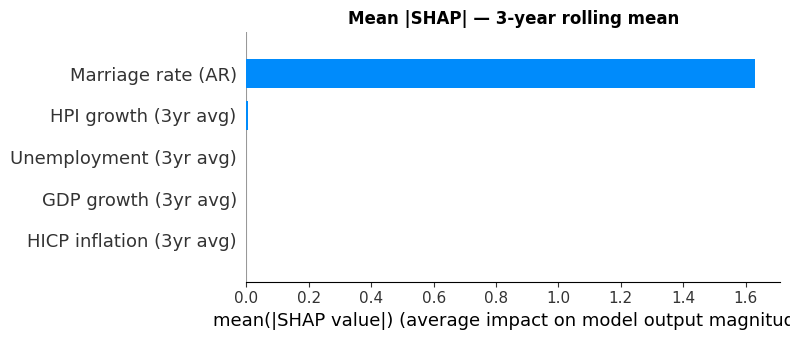

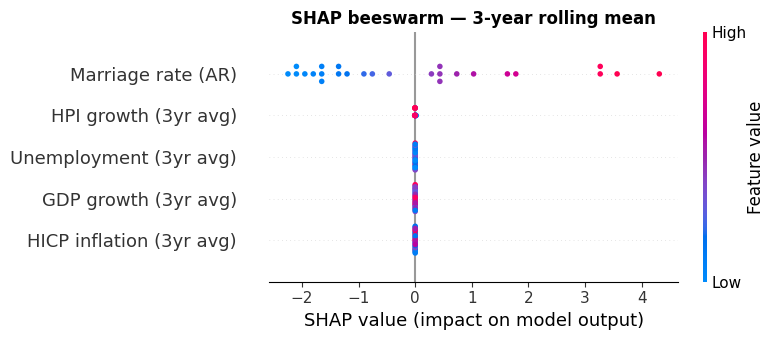

In [11]:
feat_labels = ['HPI growth (3yr avg)', 'HICP inflation (3yr avg)', 'GDP growth (3yr avg)', 'Unemployment (3yr avg)', 'Marriage rate (AR)']

explainer   = shap.LinearExplainer(best_model, X_train)
shap_values = explainer(X_train)

shap.summary_plot(shap_values.values, X_train, feature_names=feat_labels, plot_type="bar", show=False)
plt.title("Mean |SHAP| — 3-year rolling mean", fontweight="bold")
plt.tight_layout()
plt.savefig("figures/lr_shap_bar_roll3mean.png", dpi=200, bbox_inches="tight")
plt.show()

shap.summary_plot(shap_values.values, X_train, feature_names=feat_labels, show=False)
plt.title("SHAP beeswarm — 3-year rolling mean", fontweight="bold")
plt.tight_layout()
plt.savefig("figures/lr_shap_beeswarm_roll3mean.png", dpi=200, bbox_inches="tight")
plt.show()

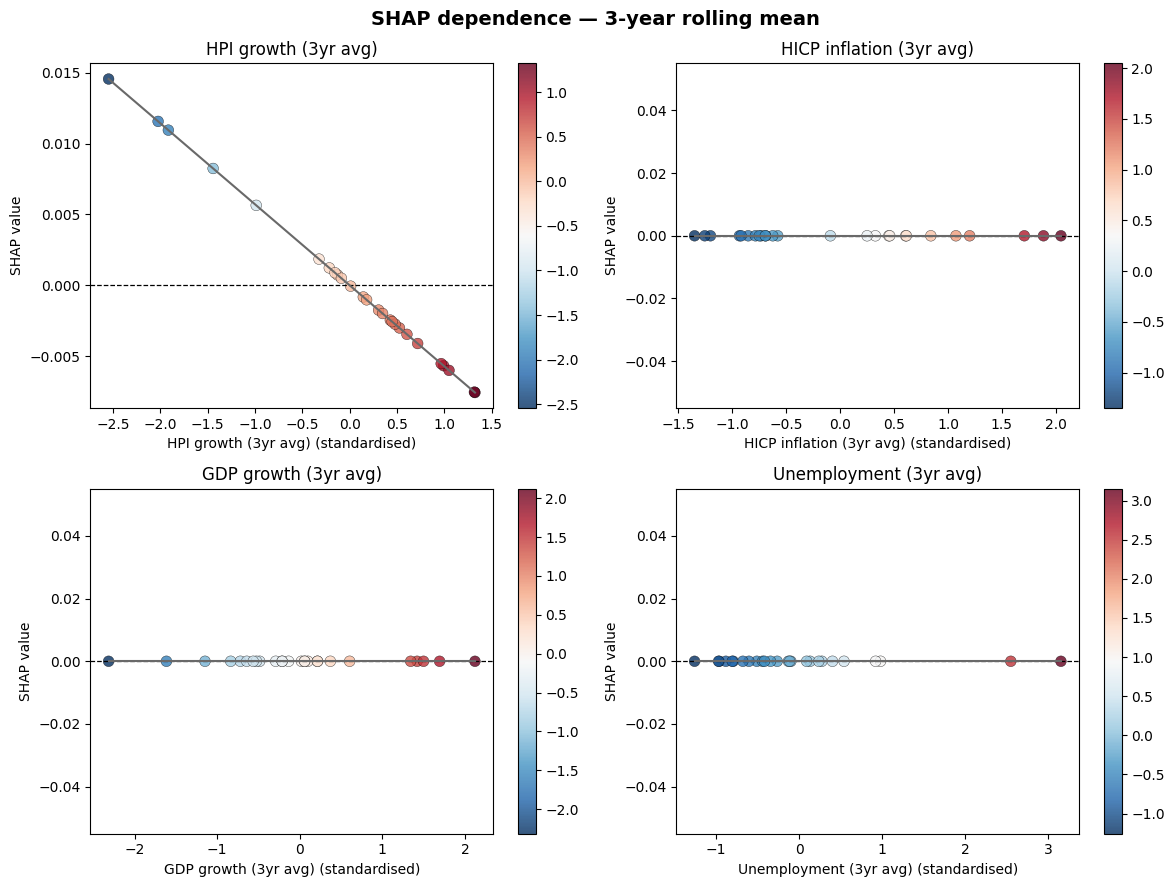

In [12]:
feat_labels = ['HPI growth (3yr avg)', 'HICP inflation (3yr avg)', 'GDP growth (3yr avg)', 'Unemployment (3yr avg)']

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
fig.suptitle("SHAP dependence — 3-year rolling mean", fontsize=14, fontweight="bold")

for i in range(4):
    ax  = axes[i // 2][i % 2]
    xv  = X_train[:, i]
    sv  = shap_values.values[:, i]

    sc = ax.scatter(xv, sv, c=xv, cmap="RdBu_r", alpha=0.8, edgecolors="k", linewidths=0.3, s=60)
    ax.axhline(0, color="k", linestyle="--", linewidth=0.9)
    m, b = np.polyfit(xv, sv, 1)
    xs   = np.linspace(xv.min(), xv.max(), 100)
    ax.plot(xs, m * xs + b, color="dimgray", linewidth=1.5)
    ax.set_xlabel(f"{feat_labels[i]} (standardised)")
    ax.set_ylabel("SHAP value")
    ax.set_title(feat_labels[i])
    plt.colorbar(sc, ax=ax)

plt.tight_layout()
plt.savefig("figures/lr_shap_dep_roll3mean.png", dpi=200, bbox_inches="tight")
plt.show()